## Transcriptomics Quality Check



In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from corneto.io import import_cobra_model
from cobra.io import read_sbml_model

 Loading the Data

In [2]:
# Load your data (genes as rows, samples as columns)
df = pd.read_csv('/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Buniformis/Buniformis_All.csv', index_col=0)  
model = read_sbml_model("/scratch/rebernig/VR002_Model_Analysis/Output/Curated_Models_Elena/B.Uniformis/Confidence_Levels_Biomass/curated.xml")
df = np.log2(df + 1)
df

,sample1,sample5,sample9,sample13,sample16,sample19,sample45,sample46,sample85,sample15,sample18,sample21
Name,,,,,,,,,,,,
BU_ATCC8492_00001,2.530177,2.491529,3.061421,3.817083,3.121127,1.991691,8.382024,8.202651,7.837876,4.474668,5.235715,3.385136
BU_ATCC8492_00002,6.654043,5.298308,3.836880,6.745566,6.194652,5.206708,2.557282,4.376564,7.342388,5.123856,3.537682,5.016012
BU_ATCC8492_00003,3.830043,2.614046,1.260462,4.373436,3.525233,3.386663,8.631854,8.533239,8.823847,1.264038,1.548946,2.003491
BU_ATCC8492_00004,7.434048,7.132679,7.213673,7.934817,8.037151,6.744675,11.700556,11.642850,11.809415,7.985595,9.219988,7.195924
BU_ATCC8492_00005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.086683
...,...,...,...,...,...,...,...,...,...,...,...,...
BU_ATCC8492_03904,5.603424,4.586851,3.899594,4.802016,3.607362,3.921715,7.122585,7.946830,8.022345,7.349090,7.143607,4.942044
BU_ATCC8492_03905,4.450900,3.019822,3.660271,4.476792,2.627871,2.473073,6.110516,5.457605,6.453276,5.403992,5.177867,4.975403
BU_ATCC8492_03906,5.333547,5.051160,4.031584,6.163987,5.419039,4.118000,6.204543,6.569958,7.242912,5.982328,5.741238,6.423454


### Spearman correlation (better for non-linear)

In [3]:
sample_to_condition = {
    'sample1': 'Buniformis',
    'sample5': 'Buniformis',
    'sample9': 'Buniformis',
    'sample13': 'Buniformis + BTheta',
    'sample16': 'Buniformis + BTheta',
    'sample19': 'Buniformis + BTheta',
    'sample45': 'Com21',
    'sample46': 'Com21',
    'sample85': 'Com21',
    'sample15': 'P.vulgatus + Buniformis',
    'sample18': 'P.vulgatus + Buniformis',
    'sample21': 'P.vulgatus + Buniformis'
}

/tmp/ipykernel_663159/3965359082.py:5: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df_conditions.groupby(df_conditions.columns, axis=1).mean()


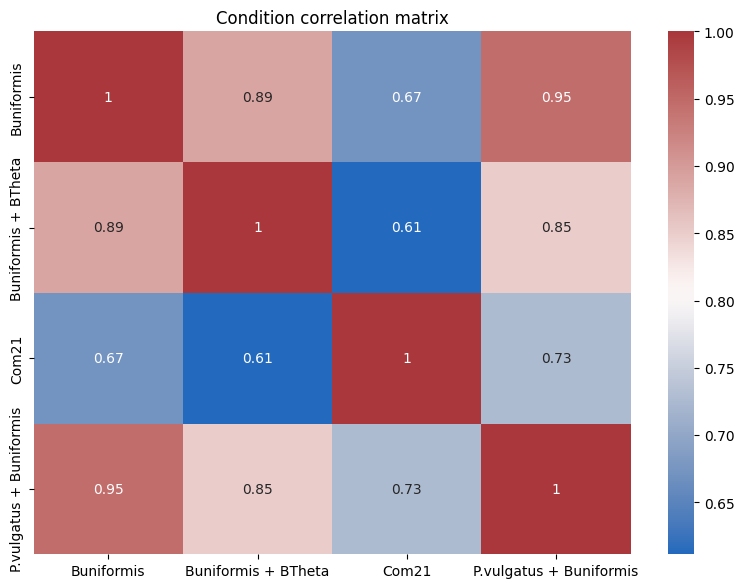

In [5]:
# Map sample names → condition names
df_conditions = df.rename(columns=sample_to_condition)

# If you have replicates (same condition multiple times), average them
df_grouped = df_conditions.groupby(df_conditions.columns, axis=1).mean()

# Compute correlation (Spearman as in your code)
corr = df_grouped.corr(method='spearman')

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='vlag')
plt.title('Condition correlation matrix')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Correlation_Test/Buniformis_Correlation_byCondition.png")
plt.show()

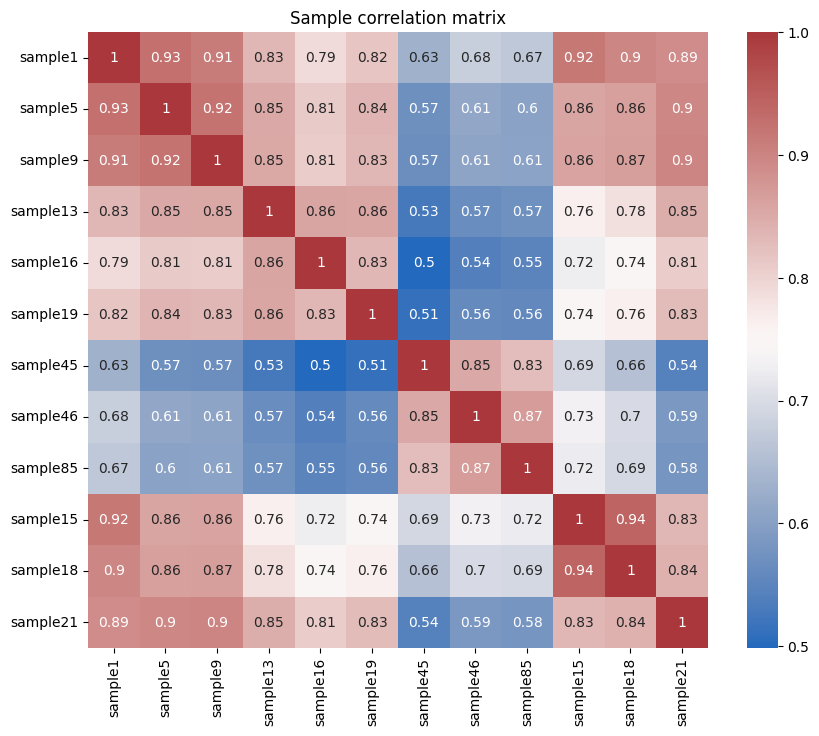

In [5]:
df.corr()
corr = df.corr(method='spearman')


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='vlag')
plt.title('Sample correlation matrix')
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Correlation_Test/Buniformis_Correlation")
plt.show()

Now a re clearer matrix, with blue < 0.80 < red

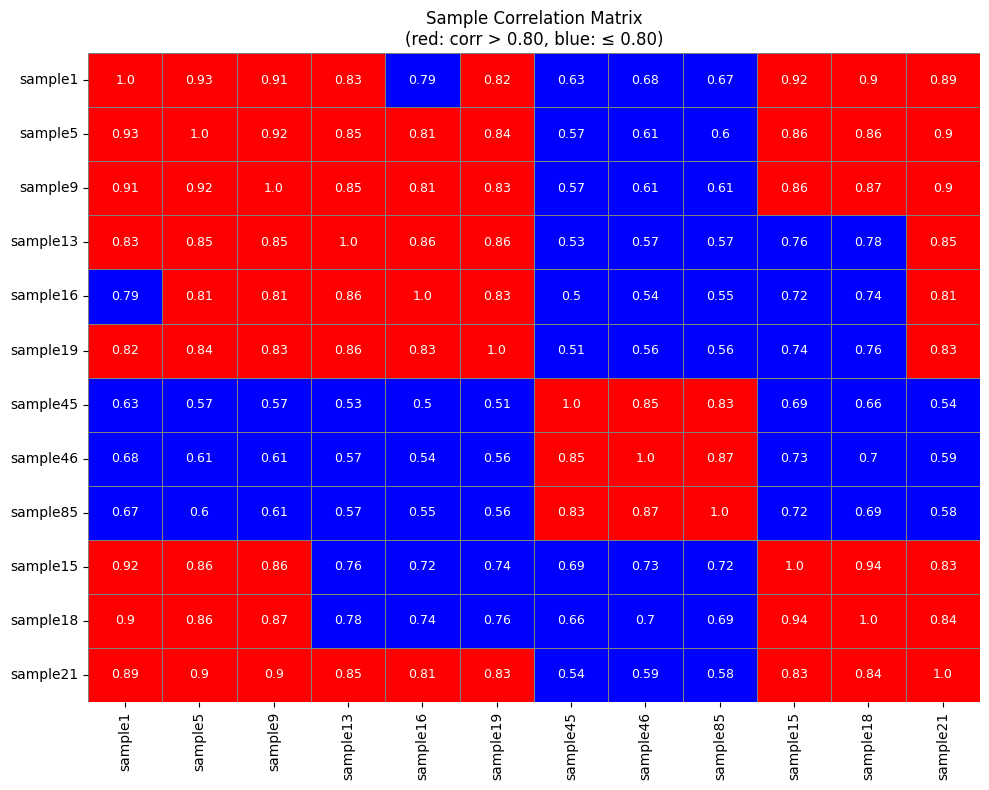

In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# Make a copy of the correlation matrix for coloring
# Make a new matrix with values: 0 for ≤0.8, 1 for >0.8
mask_matrix = (corr.values > 0.80).astype(int)

cmap = ListedColormap(['blue', 'red'])
bounds = [-0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10,8))
sns.heatmap(
    mask_matrix, annot=corr.round(2), fmt='', 
    cmap=cmap, norm=norm, cbar=False, linewidths=0.5, linecolor='gray',
    xticklabels=corr.columns, yticklabels=corr.index, annot_kws={'fontsize':9}
)
plt.title('Sample Correlation Matrix\n(red: corr > 0.80, blue: ≤ 0.80)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

1) We can see weak correlation between sample14 and sample20 even they are both a biological replicates from Pvulgatus&Btheta
2) Weak correlation also between sample 15 and 21 both from B.Uniformis&Pvulgatus
3) Strong correlation between nearly all samples of P.vulgatus&B.theta and P.vulgatus&B.uniformis - seems already not to change much in the expression of P-vulgatus

### PCA Test

In [7]:
# Transpose: samples as rows, genes as columns (this is what PCA expects)
df_T = df.T



In [8]:
pca = PCA(n_components=2)
pc = pca.fit_transform(df_T)
pca_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_T.index)

# Map sample to condition
sample_to_condition = {
    'sample1': 'Buniformis',
    'sample5': 'Buniformis',
    'sample9': 'Buniformis',
    'sample13': 'Buniformis + BTheta',
    'sample16': 'Buniformis + BTheta',
    'sample19': 'Buniformis + BTheta',
    'sample45': 'Com21',
    'sample46': 'Com21',
    'sample85': 'Com21',
    'sample15': 'P.vulgatus + Buniformis',
    'sample18': 'P.vulgatus + Buniformis',
    'sample21': 'P.vulgatus + Buniformis'
}

pca_df['Condition'] = pca_df.index.map(sample_to_condition)

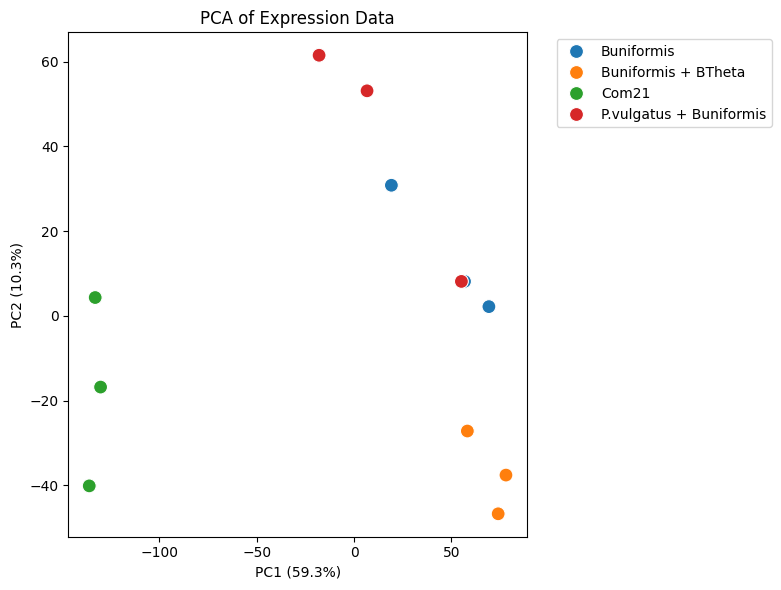

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/PCA/before_Gene_removal/Buniformis")
plt.show()

Data seems to be separated, especially between Com21 and the rest for PC1. 
 

Next, we check for strong Outliers

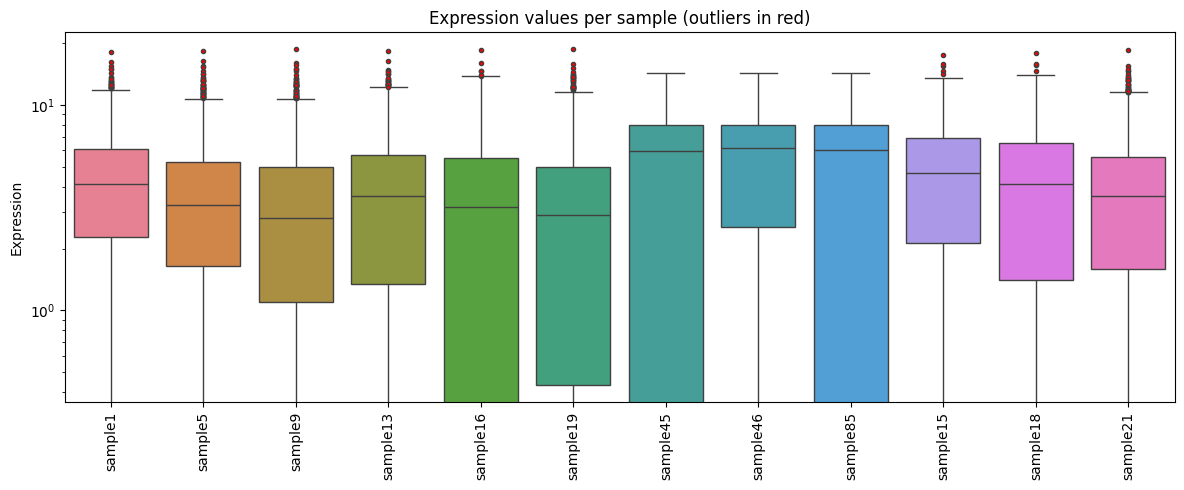

In [10]:
# Blotting Boxplots, to see outliers

plt.figure(figsize=(12,5))
sns.boxplot(data=df, orient='v', showfliers=True, fliersize=3, flierprops=dict(markerfacecolor='r', marker='o'))
plt.ylabel('Expression')
plt.title('Expression values per sample (outliers in red)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log",base=10)
plt.show()

In [11]:
max_per_gene=df.max()
max_per_gene

sample1     18.090849
sample5     18.378600
sample9     18.610387
sample13    18.244638
sample16    18.538372
sample19    18.674585
sample45    14.332627
sample46    14.319860
sample85    14.243882
sample15    17.405858
sample18    17.806320
sample21    18.503610
dtype: float64

### PCA Analyis without Outliers

Removing Outliers

In [12]:
# Create a mask for non-outlier values (True = not outlier)
mask = pd.DataFrame(True, index=df.index, columns=df.columns)
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask[col] = (df[col] >= lower) & (df[col] <= upper)

# Replace outliers with NaN
df_no_outliers = df.where(mask)

df_filled = df_no_outliers.fillna(df_no_outliers.median())

Showing the Data without Outliers

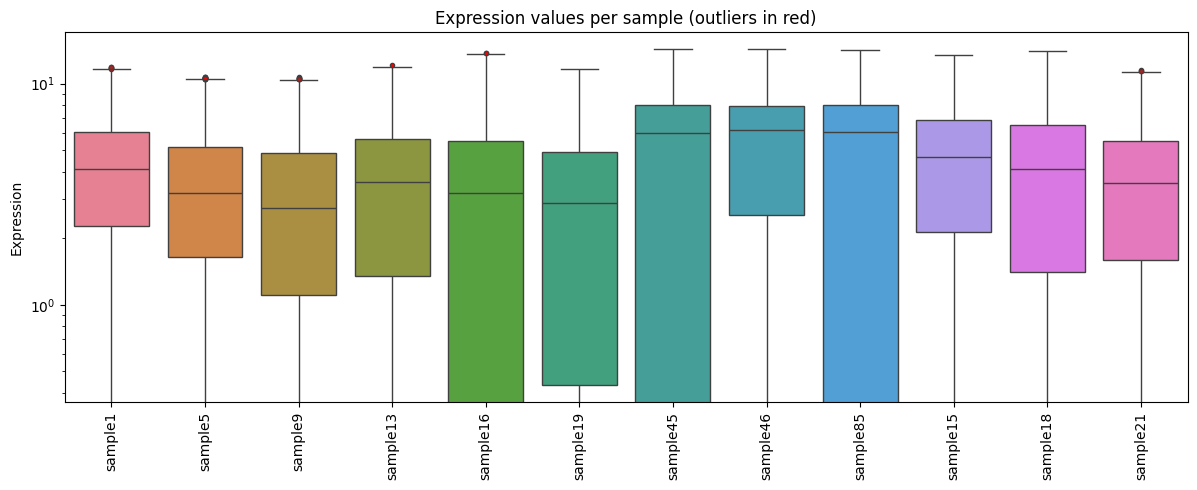

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_filled, orient='v', showfliers=True, fliersize=3, flierprops=dict(markerfacecolor='r', marker='o'))
plt.ylabel('Expression')
plt.title('Expression values per sample (outliers in red)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log",base=10)
plt.show()

Now showing it in the PCA analysis

In [14]:
# Transpose: samples as rows, genes as columns (this is what PCA expects)
df_filled_T = df_filled.T



In [15]:
pca = PCA(n_components=2)
pc = pca.fit_transform(df_filled_T)
pca_df_filled = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_filled_T.index)

In [16]:
pca_df_filled['Condition'] = pca_df_filled.index.map(sample_to_condition)

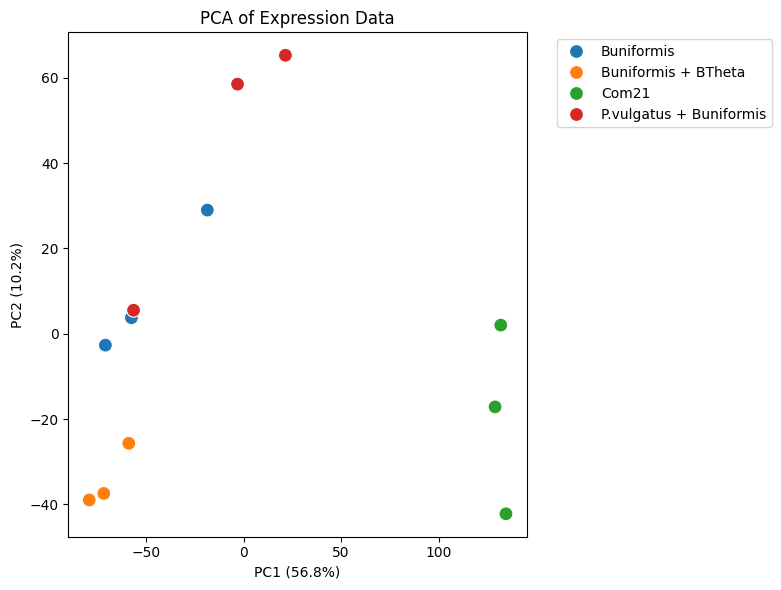

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df_filled, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Differences are minimal compared to the dataset with outliers

## Which Genes have high weight on PC2

Analysing min and max weights for PC2

In [18]:
a = pca.components_[1:].flatten()

In [19]:
max = pca.feature_names_in_[a.argmax()]
min = pca.feature_names_in_[a.argmin()]
max , min


('BU_ATCC8492_02790', 'BU_ATCC8492_02350')

In [20]:
com21_samples = ['sample45', 'sample46', 'sample85']
df_T[df_T.index.isin(com21_samples)].BU_ATCC8492_02790 


sample45    0.000000
sample46    0.000000
sample85    8.124764
Name: BU_ATCC8492_02790, dtype: float64

In [21]:
com21_samples = ['sample45', 'sample46', 'sample85']
df_T[df_T.index.isin(com21_samples)].BU_ATCC8492_02350

sample45    9.519218
sample46    2.700789
sample85    7.927411
Name: BU_ATCC8492_02350, dtype: float64

We can see that weigths are coming from genes, in which at least on of the sample has no expression at all. 

## Data Cleaning - Removing of additional genes

Therefore, I further remove each Gene for a sample, if not all replicates have expression levels. Additonaly, I will remove all genes, which are not used in my model

1) First, look at the genes in our model 

In [22]:
# Get all gene objects
genes = model.genes

# Get gene IDs as a list
gene_ids = [gene.id for gene in genes]

# Print or save
print("Total genes:", len(gene_ids))
print(gene_ids[:10])  # print first 10 for a check

model_gene_set = set(gene_ids)

Total genes: 623
['BU_ATCC8492_00782', 'BU_ATCC8492_02920', 'BU_ATCC8492_03086', 'BU_ATCC8492_02001', 'BU_ATCC8492_03455', 'BU_ATCC8492_03100', 'BU_ATCC8492_03637', 'BU_ATCC8492_03785', 'BU_ATCC8492_01767', 'BU_ATCC8492_00775']


We can see 623 genes in total

2) We look at the genes in our Expression Table

In [23]:
gene_names = df.index.tolist()
print(len(gene_names))
print(gene_names[:10])

expression_gene_set = set(gene_names)

3782
['BU_ATCC8492_00001', 'BU_ATCC8492_00002', 'BU_ATCC8492_00003', 'BU_ATCC8492_00004', 'BU_ATCC8492_00005', 'BU_ATCC8492_00006', 'BU_ATCC8492_00007', 'BU_ATCC8492_00008', 'BU_ATCC8492_00009', 'BU_ATCC8492_00010']


We have 3782 genes

3) We compare now which genes from our model are in our expression table

In [24]:
Overlapping_genes = model_gene_set & expression_gene_set

print(len(Overlapping_genes))
print(Overlapping_genes)


607
{'BU_ATCC8492_03115', 'BU_ATCC8492_01840', 'BU_ATCC8492_02928', 'BU_ATCC8492_00171', 'BU_ATCC8492_00685', 'BU_ATCC8492_01530', 'BU_ATCC8492_00508', 'BU_ATCC8492_03525', 'BU_ATCC8492_03637', 'BU_ATCC8492_02020', 'BU_ATCC8492_02333', 'BU_ATCC8492_01821', 'BU_ATCC8492_01207', 'BU_ATCC8492_00989', 'BU_ATCC8492_03288', 'BU_ATCC8492_01139', 'BU_ATCC8492_02495', 'BU_ATCC8492_00461', 'BU_ATCC8492_02460', 'BU_ATCC8492_01614', 'BU_ATCC8492_02085', 'BU_ATCC8492_01990', 'BU_ATCC8492_00526', 'BU_ATCC8492_01767', 'BU_ATCC8492_02019', 'BU_ATCC8492_02839', 'BU_ATCC8492_00630', 'BU_ATCC8492_01150', 'BU_ATCC8492_00401', 'BU_ATCC8492_03197', 'BU_ATCC8492_00106', 'BU_ATCC8492_02382', 'BU_ATCC8492_03438', 'BU_ATCC8492_02479', 'BU_ATCC8492_03043', 'BU_ATCC8492_03035', 'BU_ATCC8492_02346', 'BU_ATCC8492_01361', 'BU_ATCC8492_00629', 'BU_ATCC8492_03715', 'BU_ATCC8492_03322', 'BU_ATCC8492_01626', 'BU_ATCC8492_01071', 'BU_ATCC8492_02471', 'BU_ATCC8492_03408', 'BU_ATCC8492_03192', 'BU_ATCC8492_03693', 'BU_ATCC

In [29]:
Modelgenes_not_in_overlapping = model_gene_set - Overlapping_genes
Modelgenes_not_in_overlapping

{'BU_ATCC8492_01923',
 'BU_ATCC8492_03547',
 'PV_ATCC8482_00305',
 'PV_ATCC8482_00403',
 'PV_ATCC8482_00477',
 'PV_ATCC8482_01087',
 'PV_ATCC8482_01088',
 'PV_ATCC8482_01109',
 'PV_ATCC8482_01542',
 'PV_ATCC8482_01901',
 'PV_ATCC8482_01971',
 'PV_ATCC8482_02320',
 'PV_ATCC8482_02799',
 'PV_ATCC8482_03114',
 'PV_ATCC8482_04092',
 'PV_ATCC8482_04258'}

Next all the genes, which are not overlapping between the model and the gene expression table are removed 

In [25]:
filtered_df = df.loc[df.index.intersection(Overlapping_genes)]
len(filtered_df)
filtered_df.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Data_cleaning/Filtered_BU/filtered_BU.csv")

A dataset with only the genes used in the model, was created. 

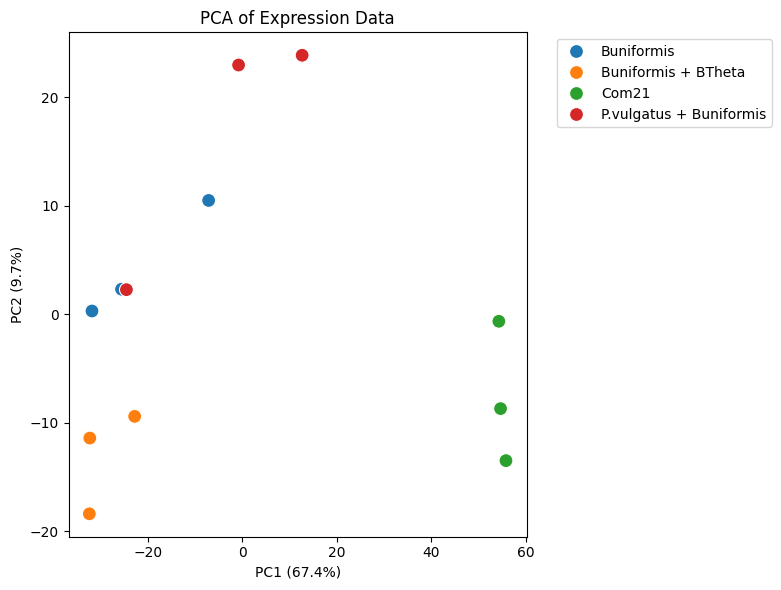

In [26]:


# 2. Transpose so samples are rows, genes are columns
filtered_df_T = filtered_df.T

# 4. Run PCA
pca = PCA(n_components=2)
pc = pca.fit_transform(filtered_df_T)
pca_masked_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=filtered_df_T.index)

# 5. Map sample names to conditions (make sure you have this dictionary!)

pca_masked_df['Condition'] = pca_masked_df.index.map(sample_to_condition)

# 6. Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_masked_df, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/PCA/after_gene_removal/Buniformis")
plt.show()

## Mean-Variance Blot of new cleaned Data

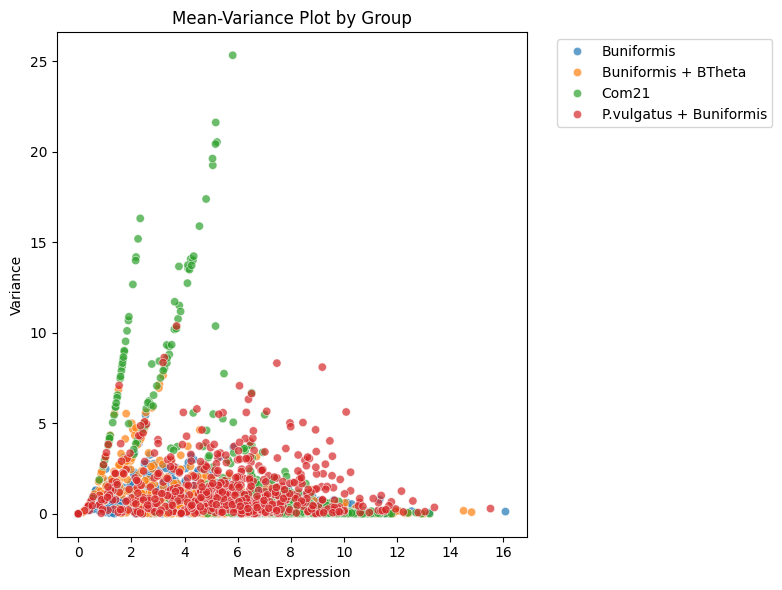

In [27]:
# Create group info DataFrame
group_df = pd.Series(sample_to_condition).to_frame('Group')

# Calculate mean/variance per group per gene
grouped = {}
for group in group_df['Group'].unique():
    cols = group_df[group_df['Group'] == group].index
    means = filtered_df[cols].mean(axis=1)
    variances = filtered_df[cols].var(axis=1)
    grouped[group] = pd.DataFrame({'Gene': filtered_df.index, 'Mean': means, 'Variance': variances, 'Group': group})

mv_df = pd.concat(grouped.values(), ignore_index=True)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=mv_df, x='Mean', y='Variance', hue='Group', alpha=0.7)
plt.title("Mean-Variance Plot by Group")
plt.xlabel("Mean Expression")
plt.ylabel("Variance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Mean-Variance_Blot/BUniformis_combined")
plt.show()

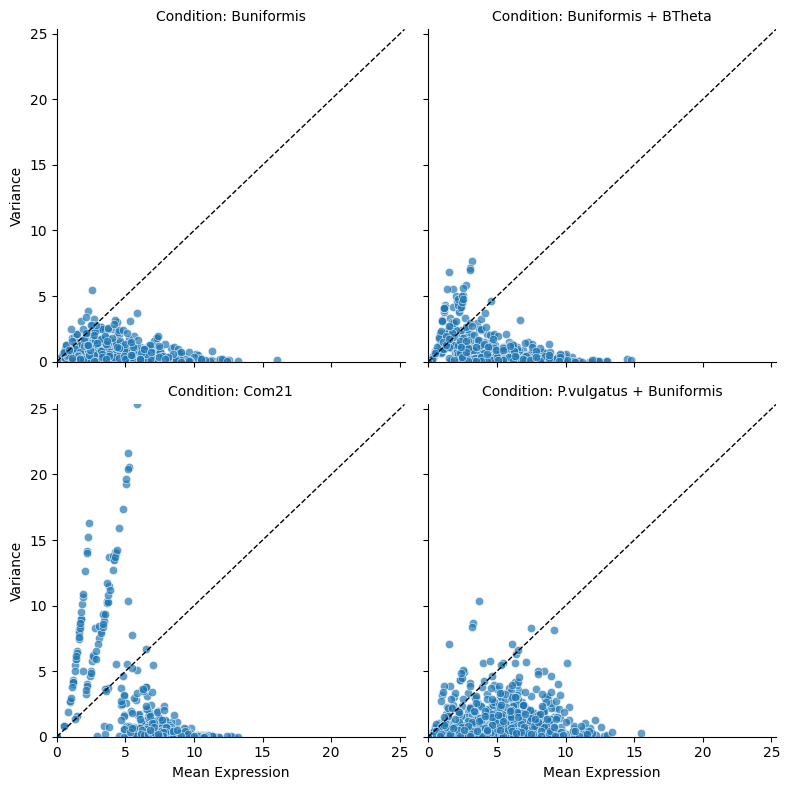

In [28]:
# Overall limits so facets are comparable
global_min = np.nanmin(mv_df[['Mean','Variance']].values)
global_max = np.nanmax(mv_df[['Mean','Variance']].values)
lims = [global_min, global_max]

g = sns.FacetGrid(mv_df, col='Group', col_wrap=2, sharex=True, sharey=True, height=4)

# Scatter in each facet
g.map_dataframe(sns.scatterplot, x='Mean', y='Variance', alpha=0.7)

# Add the diagonal in each facet
def add_diag(data, **kws):
    ax = plt.gca()
    ax.plot(lims, lims, ls='--', color='k', lw=1)

g.map_dataframe(add_diag)

# Tidy up
g.set_axis_labels("Mean Expression", "Variance")
g.set_titles("Condition: {col_name}")
for ax in g.axes.flat:
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Mean-Variance_Blot/BUniformis_single")
plt.show()